# Placing a STARmap section in the Allen CCF

A 2D section fitted into a 3D reference volume, entirely through squidpy's public API:
`rasterize_points` → `align_stalign_volume` → `Stalign3DResult.transform` → `sample_volume`.


## Inputs

Cells as a points element, the atlas and its annotation volume as 3D images. The physical
placement lives on the elements, so nothing downstream builds coordinate axes by hand.


In [1]:
import nrrd, numpy as np, pandas as pd, spatialdata as sd
from spatialdata.models import Image3DModel, PointsModel
from spatialdata.transformations import Scale, Sequence, Translation

cells = pd.read_csv('starmap_data/well11_spatial.csv.gz')
xy = np.c_[np.array(cells['X'])[1:], np.array(cells['Y'])[1:]].astype(float)

atlas, hdr = nrrd.read('ara_nissl_50.nrrd')       # (z, y, x)
labels, _ = nrrd.read('annotation_50.nrrd')       # same frame, integer structure ids
voxel = tuple(np.diag(hdr['space directions']))

def centred(shape, spacing, axes):
    """The placement an atlas volume carries: voxel size, and the origin at its centre."""
    return Sequence([
        Scale(list(spacing), axes=axes),
        Translation(-(np.asarray(shape) - 1) * np.asarray(spacing) / 2, axes=axes),
    ])

sdata = sd.SpatialData(
    points={'cells': PointsModel.parse(xy)},
    images={'atlas': Image3DModel.parse(
        atlas[None].astype(float), dims=('c', 'z', 'y', 'x'),
        transformations={'global': centred(atlas.shape, voxel, ('z', 'y', 'x'))},
    )},
)
sdata



/localscratch/selman.ozleyen/stalign-nb-39766852/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SpatialData object
├── Images
│     └── 'atlas': DataArray[czyx] (1, 264, 160, 228)
└── Points
      └── 'cells': DataFrame with shape: (<Delayed>, 2) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        atlas (Images), cells (Points)

## The section

`rasterize_points` turns the centroids into a density image: each cell deposits unit mass
bilinearly, blurred once per scale, so total intensity is exactly the cell count.


In [2]:
from squidpy.experimental.im import rasterize_points

rasterize_points(sdata, 'cells', dx=50.0, blur=1.0, key_added='section')
sdata['section']


<xarray.DataArray 'image' (c: 1, y: 563, x: 760)> Size: 3MB
dask.array<array, shape=(1, 563, 760), dtype=float64, chunksize=(1, 563, 760), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 8B 0
  * y        (y) float64 5kB 0.5 1.5 2.5 3.5 4.5 ... 559.5 560.5 561.5 562.5
  * x        (x) float64 6kB 0.5 1.5 2.5 3.5 4.5 ... 756.5 757.5 758.5 759.5
Attributes:
    transform:  {'global': Sequence \n    Scale (y, x)\n        [50. 50.]\n  ...

## The fit

`initial_slice`, `initial_rotation` and `initial_scale` are an initialisation, not the answer —
the full 3D deformation is fitted, so the section need not be exactly coronal.


In [3]:
from spatialdata.transformations import get_transformation
from squidpy.experimental.tl import align_stalign_volume

def physical_axes(element, axes):
    """Physical coordinate vector per axis, in array order.

    An element's `.coords` are pixel indices (0.5, 1.5, ...), not physical units -- the
    placement lives in the element's transformation. Reading `.coords` directly and treating
    it as microns silently replaces 425 um of depth with 140, which is a fit that starts in
    the wrong place and never recovers.
    """
    matrix = get_transformation(element, 'global').to_affine_matrix(input_axes=axes, output_axes=axes)
    return [(np.asarray(element.coords[a]) - 0.5) * matrix[k, k] + matrix[k, -1]
            for k, a in enumerate(axes)]

# `initial_scale` is one uniform factor for all three axes, and this dataset is anisotropic:
# ~4x in plane, ~0.9x through the slice axis. `initial_affine` is the escape hatch.
#
# Built in the solver's (z, y, x) and reversed once at the end. Composing it directly in
# (x, y, z) means hand-transposing a rotation, two scales and three translations, and each is
# a chance to mirror an axis silently -- so the reversal gets exactly one line.
theta, scale_xy, scale_z, slice_index = np.pi / 2, 4.0, 0.9, 140
z_axis, _, _ = physical_axes(sdata['atlas'], ('z', 'y', 'x'))
y_axis, x_axis = physical_axes(sdata['section'], ('y', 'x'))

# The one landmark this analysis pins: atlas (0, 0) sits at (-3700, 0) in the section, in (-y, -x).
landmark_yx = np.array([-3700.0, 0.0])

rotation = np.array([[1.0, 0.0, 0.0],
                     [0.0, np.cos(theta), -np.sin(theta)],
                     [0.0, np.sin(theta), np.cos(theta)]])
affine_zyx = np.eye(4)
affine_zyx[:3, :3] = rotation @ np.diag([scale_z, scale_xy, scale_xy])
affine_zyx[:3, 3] = [-z_axis[slice_index],
                     y_axis.mean() - landmark_yx[0] * scale_xy,
                     x_axis.mean() - landmark_yx[1] * scale_xy]

reverse = np.eye(4)[[2, 1, 0, 3]]          # spatial axes only; the homogeneous row stays put
initial_affine = reverse @ affine_zyx @ reverse

SOLVER = dict(a=250.0, nt=4, sigmaM=0.1, sigmaA=0.1, sigmaB=0.1, muA=[0.7], muB=[0.0])


### Is the initialisation in the right place?

`niter=0` returns the starting affine without fitting, so the initial guess can be looked at
through the same public route as the result. Worth doing: an initialisation that starts in the
wrong place produces a fit that never recovers, and the objective alone does not say so.


In [4]:
guess = align_stalign_volume(
    sdata, image_key=('atlas', 'section'), initial_affine=initial_affine, niter=0, **SOLVER
)

def atlas_at(result):
    """The atlas resampled onto the section's plane, through a fit's own backward map."""
    plane = np.moveaxis(np.asarray(result.deformation_grid(direction='backward')), 0, -1)[0]
    sampled = sample_volume(atlas, result.ref_axes, plane.reshape(-1, 3)[:, ::-1])
    return sampled.reshape(plane.shape[:2])

initial_depth = np.asarray(guess.transform(xy))[:, 2]
print(f'initial guess places the section at z = {initial_depth.mean():.0f} um '
      f'(slice {slice_index} sits at {z_axis[slice_index]:.0f} um)')


initial guess places the section at z = 472 um (slice 140 sits at 425 um)


In [5]:
fit = align_stalign_volume(
    sdata, image_key=('atlas', 'section'), initial_affine=initial_affine, niter=800, **SOLVER
)
print(f'{fit.n_iter} iterations, objective {float(fit.energies[0]):.0f} -> {float(fit.energies[-1]):.0f}')


800 iterations, objective 92151 -> 74071


A fit that is still descending at its last iteration reports where it ran out of budget, not
where the optimum is — so look at the trace before trusting the result.


last tenth: mean 76207, spread 20904


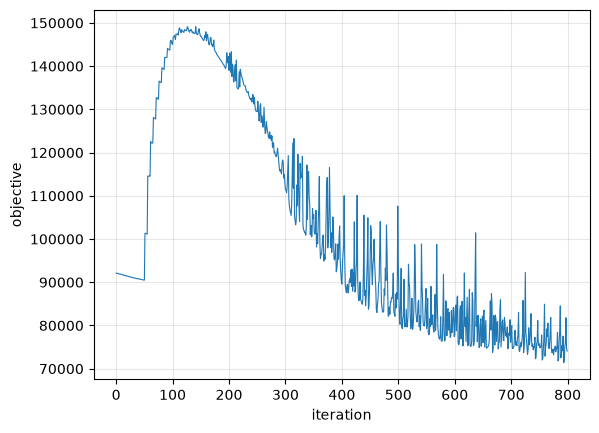

In [6]:
import matplotlib.pyplot as plt

energies = np.asarray(fit.energies)[: fit.n_iter]
tail = energies[-len(energies) // 10 :]
print(f'last tenth: mean {tail.mean():.0f}, spread {np.ptp(tail):.0f}')
plt.plot(energies, lw=0.8); plt.xlabel('iteration'); plt.ylabel('objective'); plt.grid(alpha=0.3)


## Where each cell lands

`transform` maps `(x, y)` section coordinates to `(x, y, z)` reference coordinates, evaluated at
each point rather than at the nearest raster cell. `sample_volume` then reads the annotation
volume there — `order=0` because structure ids must not be interpolated.


In [7]:
from squidpy.experimental.im import sample_volume

coords = np.asarray(fit.transform(xy))                 # (N, 3), (x, y, z) in microns
structure_id = sample_volume(labels, fit.ref_axes, coords, order=0).astype(int)

print(f'{len(coords)} cells placed, {np.unique(structure_id).size} distinct structures')
print(f'depth (z) spans {coords[:, 2].min():.0f} to {coords[:, 2].max():.0f} um')


43341 cells placed, 171 distinct structures
depth (z) spans 347 to 809 um


Structure ids become acronyms through the Allen ontology.


In [8]:
ontology = pd.read_csv('allen_ontology.csv').set_index('id')['acronym']
acronym = pd.Series(structure_id).map(ontology).fillna('unassigned')
acronym.value_counts().head(12)


CP            1542
MEA           1360
CA1           1303
VPM           1247
PIR           1230
DG-sg         1214
HY             902
or             851
LHA            760
unassigned     757
SSp-bfd6a      713
DMH            685
Name: count, dtype: int64

## The aligned atlas over the section


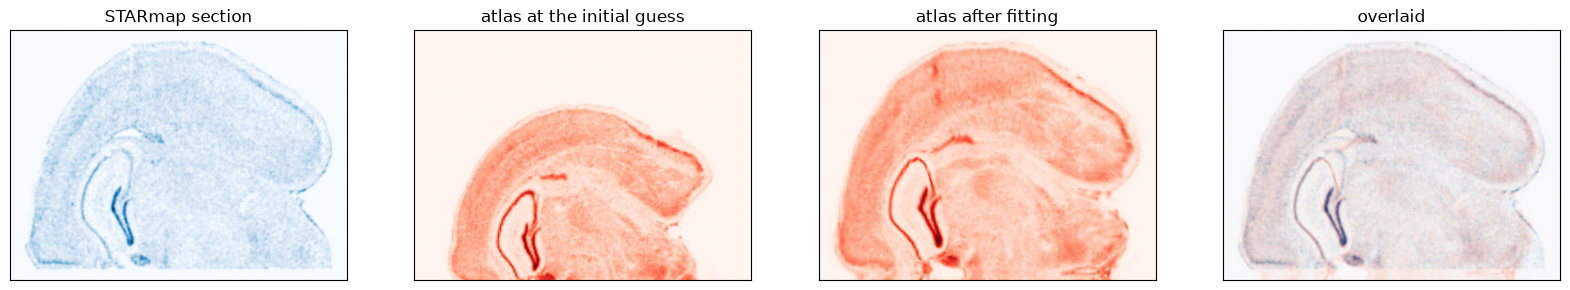

In [9]:
import matplotlib as mpl

section = np.asarray(sdata['section']).squeeze()
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(section, cmap=mpl.cm.Blues)
ax[1].imshow(atlas_at(guess), cmap=mpl.cm.Reds)
ax[2].imshow(atlas_at(fit), cmap=mpl.cm.Reds)
ax[3].imshow(section, cmap=mpl.cm.Blues, alpha=0.9)
ax[3].imshow(atlas_at(fit), cmap=mpl.cm.Reds, alpha=0.3)
for a, t in zip(ax, ('STARmap section', 'atlas at the initial guess',
                     'atlas after fitting', 'overlaid'), strict=True):
    a.set_title(t); a.set_xticks([]); a.set_yticks([])


## Cells coloured by structure


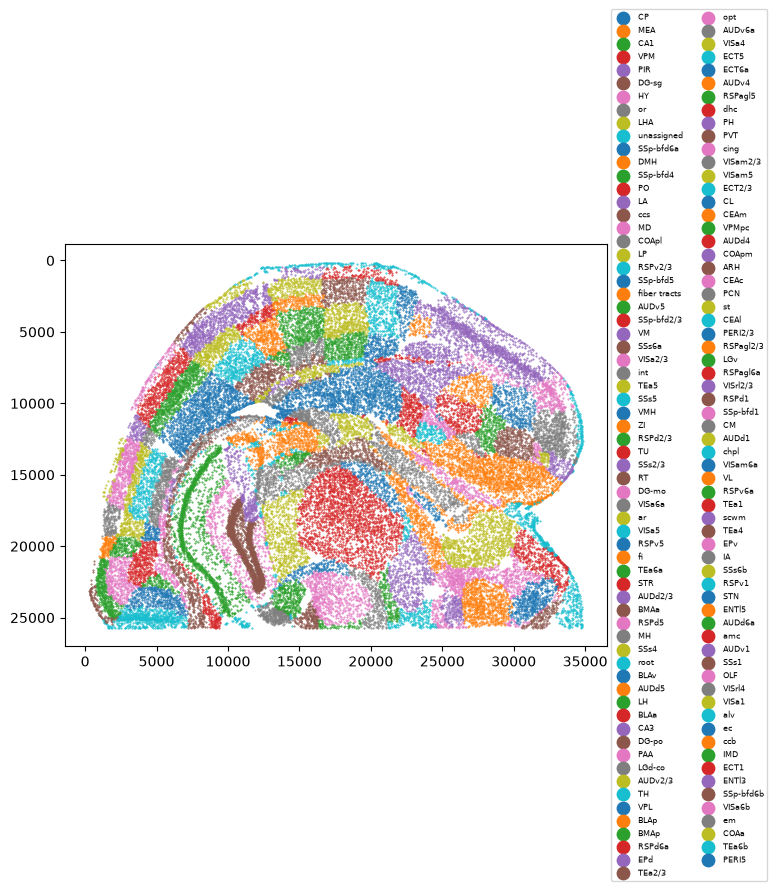

In [10]:
keep = acronym.value_counts()
keep = keep[keep >= 50].index                       # a legend of ~170 singletons reads as noise
fig, ax = plt.subplots(figsize=(7, 6))
for region in keep:
    m = (acronym == region).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=0.2, label=region)
ax.invert_yaxis(); ax.set_aspect('equal')
ax.legend(markerscale=20, fontsize=6, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))
